In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from sklearn import preprocessing
from tqdm import tqdm
from PIL import Image
import torchvision

In [34]:
pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', None)       # Auto-detect width

In [45]:
def load_data_to_dataframe(path):
    rows = []
    for activity in tqdm(list(os.scandir(path)), desc="Activities"):
        if not activity.is_dir():
            continue
        for seq in os.scandir(activity.path):
            if not seq.is_dir():
                continue
            frame_count = sum(1 for _ in os.scandir(seq.path))
            rows.append({
                "activity_seq_name": seq.name,
                "activity_seq_path": seq.path,
                "activity_seq_length": frame_count,
                "activity": activity.name
            })
    df = pd.DataFrame(rows)
    return df
df = load_data_to_dataframe("D:/ArtificialIntelligence/Projects/Trackey/trackey/research/HMDB51")

Activities: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 86.90it/s]


In [46]:
df.head()

,activity_seq_name,activity_seq_path,activity_seq_length,activity
0,April_09_brush_hair_u_nm_np1_ba_goo_0,D:/ArtificialIntelligence/Projects/Trackey/tra...,82,brush_hair
1,April_09_brush_hair_u_nm_np1_ba_goo_1,D:/ArtificialIntelligence/Projects/Trackey/tra...,79,brush_hair
2,April_09_brush_hair_u_nm_np1_ba_goo_2,D:/ArtificialIntelligence/Projects/Trackey/tra...,65,brush_hair
3,atempting_to_brush_my_hair_brush_hair_u_nm_np2...,D:/ArtificialIntelligence/Projects/Trackey/tra...,32,brush_hair
4,atempting_to_brush_my_hair_brush_hair_u_nm_np2...,D:/ArtificialIntelligence/Projects/Trackey/tra...,26,brush_hair


In [48]:
len(df['activity'].unique())

51

In [64]:
def encode_catagorical_data(df, target_col='activity'):
    enc = preprocessing.OneHotEncoder()
    enc.fit(np.array(df[target_col]).reshape(-1,1))
    return enc.transform(np.array(df[target_col]).reshape(-1,1))
encode_catagorical_data(df)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6766 stored elements and shape (6766, 51)>

In [65]:
len(df)

6766

In [66]:
df.head()

,activity_seq_name,activity_seq_path,activity_seq_length,activity
0,April_09_brush_hair_u_nm_np1_ba_goo_0,D:/ArtificialIntelligence/Projects/Trackey/tra...,82,brush_hair
1,April_09_brush_hair_u_nm_np1_ba_goo_1,D:/ArtificialIntelligence/Projects/Trackey/tra...,79,brush_hair
2,April_09_brush_hair_u_nm_np1_ba_goo_2,D:/ArtificialIntelligence/Projects/Trackey/tra...,65,brush_hair
3,atempting_to_brush_my_hair_brush_hair_u_nm_np2...,D:/ArtificialIntelligence/Projects/Trackey/tra...,32,brush_hair
4,atempting_to_brush_my_hair_brush_hair_u_nm_np2...,D:/ArtificialIntelligence/Projects/Trackey/tra...,26,brush_hair


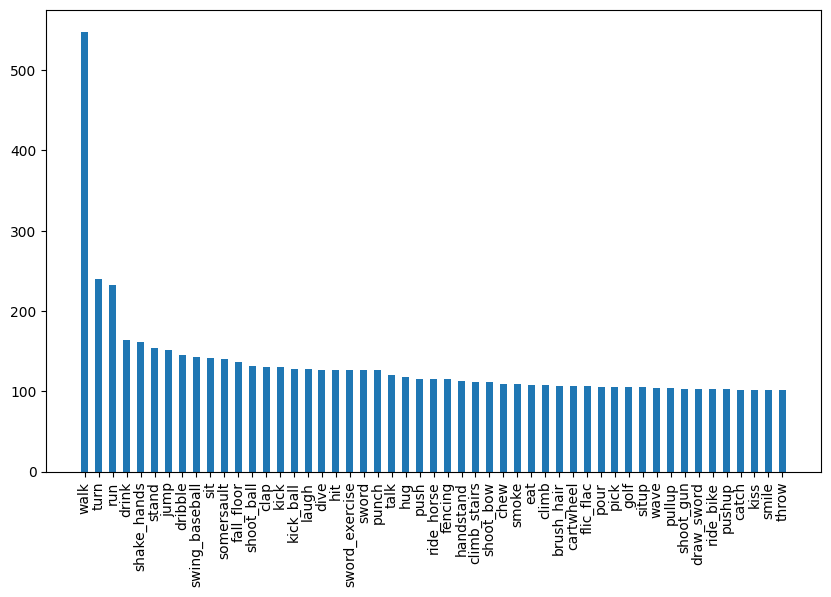

In [83]:
def plot_activity_histogram(df, activity_col = 'activity'):
    # print(df[activity_col].value_counts())
    # df[activity_col].value_counts().plot(kind='bar', xlabel='Activity', ylabel='Count', rot=0)
    plt.figure(figsize=(10, 6))
    plt.bar(df[activity_col].value_counts().keys(), height=df[activity_col].value_counts(), width=0.5)
    plt.xticks(rotation='vertical')
    plt.show()
plot_activity_histogram(df)

In [96]:
path = df.loc[0]["activity_seq_path"]
np.array(Image.open(f"{path}/10000.jpg")).shape

(240, 320, 3)

In [120]:
def load_sequence(sequence_path) -> np.ndarray:
    frames = []

    for image in sorted(os.listdir(sequence_path)):
        img = np.array(Image.open(os.path.join(sequence_path, image)))
        frames.append(img)

    return np.stack(frames, axis=0)
%timeit load_sequence(df.loc[0]["activity_seq_path"])

94.4 ms ± 1.38 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [121]:
seq = load_sequence(df.loc[0]["activity_seq_path"])
seq.shape

(82, 240, 320, 3)